# Common Figures
COnly, RD, and ECA should have separate plots

## Aim to plot NPP and NUP Responses for 
- SD
- SC
- SC4n

on one plot


In [17]:
import os,glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr # to read .rds files

%matplotlib inline

In [18]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
path_rds = "/Users/ud4/Documents/FACEMDS/Models/obs_data"
path_obs_data = "/Users/ud4/Documents/FACEMDS/L2FR_Calc"
path_save_results = "/Users/ud4/Documents/FACEMDS/Figures_Paper"
#path_save_results = "/Users/ud4/Library/CloudStorage/GoogleDrive-bharat.sharma.neu@gmail.com/My Drive/Documents/PostDocORNL/Papers/Sharma_Walker_ORNL_Papers/Evaluation_Paper_Dir/Results"

In [19]:
# Load the RDS file
# read mean annual
result = pyreadr.read_r(f'{path_rds}/OBS_ax.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data = result[None]  # None is the key for the single R object in the file

# SE
result = pyreadr.read_r(f'{path_rds}/OBS_ase.rds')
my_data_se = result[None]  # None is the key for the single R object in the file

## Global Parameters

In [20]:

fnames={}
case_abr = { # case abbreviations
    "SD" : "FACE_1PFT_r2503121_SD_b4OLMTparms", 
    "SC" : "FACE_1PFT_r250210_Best_Cal",
    #"SCnew" : "FACE_1PFT_r250421_reCal",
    #"SCnV" : "FACE_1PFT_r250425_MCMCV",
    "SC4n": "FACE_1PFT_r250506_reCalN2", # d2bl fixed at 0.065, recalibration
    #"EC" : "FACE_1PFT_r250314_NoLog_CalParams",
    #"ED" : "FACE_1PFT_r2503121_ED_b4OLMTparms",

}

site_abr = { # case abbreviations
    "ORNL" : "US-ORN",
    "DUKE" : "US-DUK",
}


sites= ("US-ORN", "US-DUK")
run_cases = ["aCO2", "eCO2"]
sim_cases = [
            "COnly",
            "RD",
            "ECA",
            ]

fsize_legend = 20
fsize_ticks = 20
fsize_labels = 24

for c_abr in case_abr:
    case_id = case_abr[c_abr]
    for s_abr in site_abr:
        site = site_abr[s_abr]
        for run_case in run_cases:
            # COnly
            fnames[f"{c_abr}_{s_abr}_COnly_{run_case}"] = f"{path_in}{case_id}_processed/{case_id}_{site}_{run_case}.nc"
            # RD
            #fn = ['RD','ECA']
            for fn in ['RD','ECA']:
                fnames[f"{c_abr}_{s_abr}_{fn}_{run_case}"] = f"{path_in}{case_id}_{fn}_processed/{case_id}_{fn}_{site}_{run_case}.nc"

In [21]:
ds = {}
for idx, key in enumerate(fnames.keys()):
    print (key, ":" , fnames[key])
    ds[key] = xr.open_mfdataset(fnames[key])
    

SD_ORNL_COnly_aCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r2503121_SD_b4OLMTparms_processed/FACE_1PFT_r2503121_SD_b4OLMTparms_US-ORN_aCO2.nc
SD_ORNL_RD_aCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r2503121_SD_b4OLMTparms_RD_processed/FACE_1PFT_r2503121_SD_b4OLMTparms_RD_US-ORN_aCO2.nc
SD_ORNL_ECA_aCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r2503121_SD_b4OLMTparms_ECA_processed/FACE_1PFT_r2503121_SD_b4OLMTparms_ECA_US-ORN_aCO2.nc
SD_ORNL_COnly_eCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r2503121_SD_b4OLMTparms_processed/FACE_1PFT_r2503121_SD_b4OLMTparms_US-ORN_eCO2.nc
SD_ORNL_RD_eCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r2503121_SD_b4OLMTparms_RD_processed/FACE_1PFT_r2503121_SD_b4OLMTparms_RD_US-ORN_eCO2.nc
SD_ORNL_ECA_eCO2 : /Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_1PFT_r2503121_SD_b4OLMTparms_ECA_processed/FACE_1PFT

In [53]:

markers_list = [".", "<", "o","^",".", "<", "o","^"]
colors_list = ["red", "green", "blue", "yellow","red", "green", "blue", "yellow"] 

#def tmp_legend_name (key):
#    return key.replace("FACE_1PFT_r250210_Best_Cal_", "")
    
# How long do you want the simulation plots?
max_r_years = 150
if run_case == "spins":
    output_freq = "yearly" # spins
    multiply_factor = 1 # 365 for daily output; else 1 for yearly
else:
    output_freq = "daily" # spins
    multiply_factor = 365
    if "CO2" in run_case:
        max_r_years = 12+5

In [54]:
# dataframe of selected colms 
# relevant columns
rel_cols = ["YEAR", "co2", "site", "NPP", "NUP"]
# if you want to save the filtered dataframe to CSV
#my_data[rel_cols].to_csv("tmp/obs_a.csv")
df_obs_ax = my_data[rel_cols]
df_obs_ase = my_data_se[rel_cols]

NPP_units = "gC m-2 y-1"
NUP_units = "gN m-2 y-1"

# Filter the dataset to keep only rows where site is 'ORNL' or 'DUKE'
df_obs_ax_site = df_obs_ax[df_obs_ax['site'].isin(['ORNL', 'DUKE'])]
df_obs_ase_site = df_obs_ase[df_obs_ase['site'].isin(['ORNL', 'DUKE'])]

filter_co2 = df_obs_ase_site["co2"] == "AMB"
filter_site = df_obs_ase_site["site"] == "ORNL"
df_obs_ase_site[filter_co2][filter_site]

# arrange data into dict!
dict_obs_ax = {}
sites_o= ("ORNL", "DUKE" )
#sites_o= ( "ORNL", )

CO2_cases  = ("AMB", "ELE" )
dict_obs_ax = {}
dict_obs_ase = {} # standard error
dict_obs_aserel = {} #rel standard error = Val SE/Var
for site in sites_o:
    dict_obs_ax    [site] = {}
    dict_obs_ase   [site] = {}
    dict_obs_aserel [site] = {}
    for co2_case in CO2_cases:
        # selected values from mean
        filter_co2 = df_obs_ax_site["co2"] == co2_case
        filter_site = df_obs_ax_site["site"] == site
        dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
        # selected values from standard error
        filter_co2 = df_obs_ase_site["co2"] == co2_case
        filter_site = df_obs_ase_site["site"] == site
        dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
        dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
        dict_obs_aserel[site][co2_case][["NPP", "NUP"]] = df_obs_ase_site[filter_co2][filter_site][["NPP", "NUP"]]/df_obs_ax_site[filter_co2][filter_site][["NPP", "NUP"]]

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_59633/2440484563.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_59633/2440484563.py:37: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_59633/2440484563.py:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_59633/2440484563.py:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_59633/2440484563.py:43: UserWarn

### 1. NPP (alloc) or NPP_Growth - Response

#### Change below

In [63]:
var_obs= "NPP"
var_names = ("NPP_Growth",
    #"NPP(GPPminusRA)",
        #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
       )



ylim_variable = (0,2200)
ylim_response = (-200,600)

# plot obs? 
obs_plot = 1 # 0,1

#sim_markers = ["","<","o",">","<","^"]
#sim_markers = ["<","<","<",">","<","^"]
sim_markers = ["","","",">","<","^"]
case_lines = ["-","-","-","-","-","_"]
case_colors = ["blue", "maroon", "orange"]

#### ORNL

/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP_Growth_Response_COnly_SD-SC-SC4n_ORNL.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP_Growth_Response_RD_SD-SC-SC4n_ORNL.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP_Growth_Response_ECA_SD-SC-SC4n_ORNL.pdf


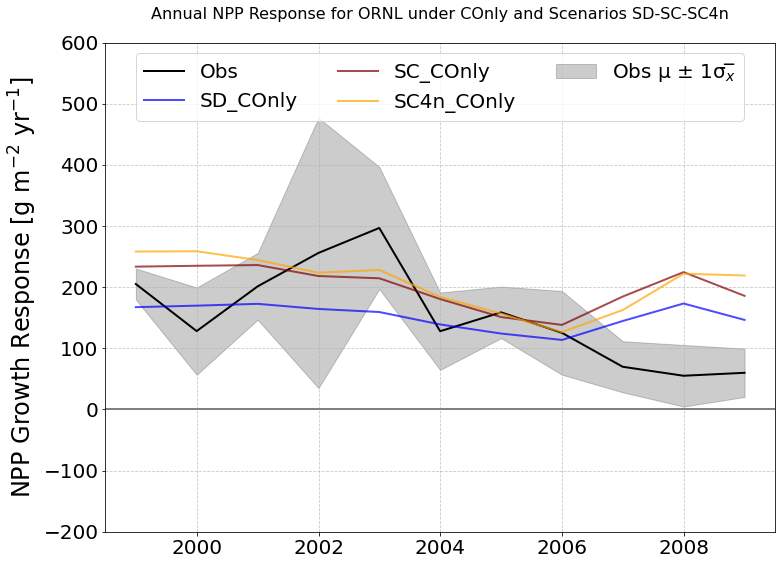

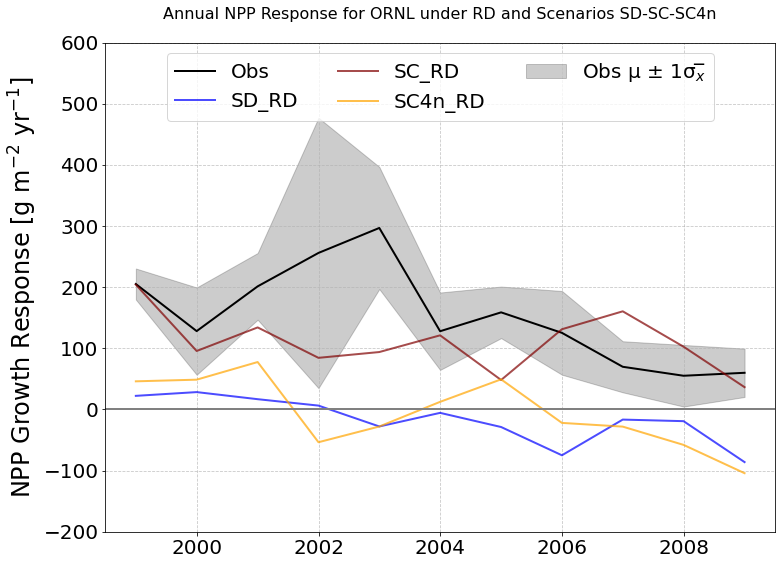

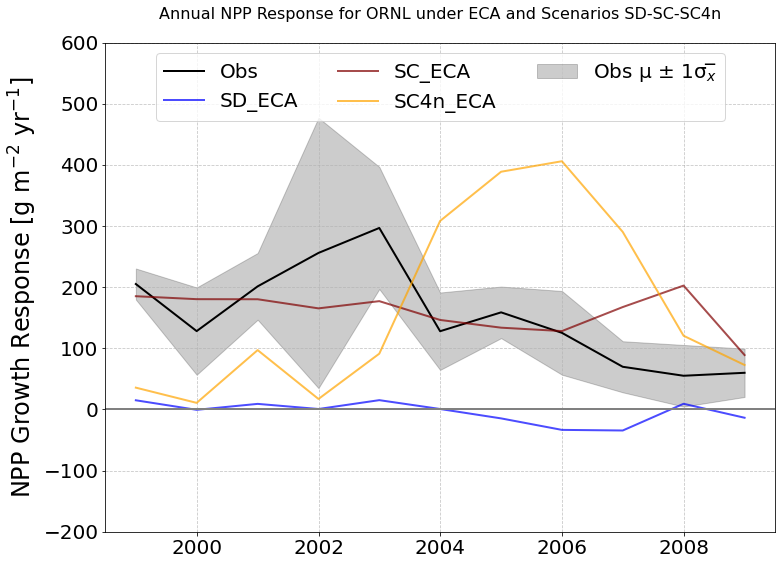

In [64]:
var_index = 0

# NPP Response for ORNL
select_site = "US-ORN"
site = "ORNL"
li = 0  # for legend index


for sim_index, sim_case in enumerate(sim_cases):
    plt.figure(figsize=(12, 9))
    ran_once = False
    for case_idx, case_plot in enumerate(list(case_abr.keys())):
        if True:
            var = var_names[var_index]
            for idx, key in enumerate(ds.keys()):
                if sim_case not in key:
                    continue
                if (f"{site}" in key) and (f"{case_plot}_" in key): 
                    time = pd.date_range(
                        "1998-01-01", "2008-12-31", freq="A"
                    )  # Monthly data
                    color_obs = "k"

                    if (obs_plot == 1) and (not ran_once):
                        Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                        Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                        Mean_DF = (
                            Mean_DF1[["YEAR", "NPP", "NUP"]]
                            - Mean_DF0[["YEAR", "NPP", "NUP"]]
                        )
                        Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                        Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                            drop=True
                        )
                        Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                            drop=True
                        )

                        Standard_error_DF = (
                            (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                            + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                        ) ** 0.5
                        Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                        tmp_case = ""

                        # Extracting the relevant columns
                        years = Mean_DF["YEAR"]
                        mean_npp = Mean_DF["NPP"]
                        se_npp = Standard_error_DF["NPP"]
                        # Plot NPP with shaded error bars
                        plt.plot(
                            time,
                            mean_npp,
                            label=f"Obs",
                            color=color_obs,
                            lw=2,
                        )
                        plt.fill_between(
                            time,
                            mean_npp - se_npp,
                            mean_npp + se_npp,
                            label=f"Obs μ ± 1σ$_x̅$",
                            color=color_obs,
                            alpha=0.2,
                        )
                        # data_plots_obs[site][var_obs][tmp_case] = {}
                        # data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                        # data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                        #plt.fill_between(
                        #    time,
                        #    mean_npp - se_npp * 1.96,
                        #    mean_npp + se_npp * 1.96,
                        #    color=color_obs,
                        #    alpha=0.15,
                        #)

                        ran_once = True

                    if "aCO2" in key:
                        #color_line = "blue"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        
                    if "eCO2" in key:
                        #color_line = "gray"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        continue
                    if var in ["FATES_NPP-FATES_EXCESS_RESP","NPP(GPPminusRA)"]:
                        tmp_var_a = (
                            (ds[key]["FATES_NPP"] - ds[key]["FATES_EXCESS_RESP"])
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        key_eCO2 = key.replace("aCO2", "eCO2")
                        tmp_var_e = (
                            (
                                ds[key_eCO2]["FATES_NPP"]
                                - ds[key_eCO2]["FATES_EXCESS_RESP"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )

                        plt.plot(
                            time,
                            (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                            label = f"{case_plot}_{sim_case}",
                            color=color_line,
                            marker=marker_line,
                            linestyle=line_style,
                            alpha=0.7,
                            linewidth=2,
                            markersize=10,
                        )
                        var_label_text = r"NPP (GPP${-}$RA)"
                    if var in ["NPP_alloc", "NPP_Growth"]:
                        tmp_var_a = (
                            (
                                ds[key]["FATES_CROOT_ALLOC"]
                                + ds[key]["FATES_FROOT_ALLOC"]
                                + ds[key]["FATES_LEAF_ALLOC"]
                                + ds[key]["FATES_SEED_ALLOC"]
                                + ds[key]["FATES_STEM_ALLOC"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        key_eCO2 = key.replace("aCO2", "eCO2")
                        tmp_var_e = (
                            (
                                ds[key_eCO2]["FATES_CROOT_ALLOC"]
                                + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                                + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                                + ds[key_eCO2]["FATES_SEED_ALLOC"]
                                + ds[key_eCO2]["FATES_STEM_ALLOC"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        plt.plot(
                            time,
                            (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                            # label=tmp_case
                            # .split("_")[-1]
                            # .replace("aCO2", "Response")
                            # + "_"
                            # + var,
                            label = f"{case_plot}_{sim_case}",
                            color=color_line,
                            marker=marker_line,
                            linestyle=line_style,
                            alpha=0.7,
                            linewidth=2,
                            markersize=10,
                        )
                        var_label_text = "NPP Growth"
                        
                    if False:
                        print(ds[key][var].long_name)
    plt.axhline(y=0, color="gray", lw=2, alpha=1)
    plt.grid(
        True, linestyle="--", alpha=0.7
    )  # Dashed grid lines with better visibility


    plt.ylabel(f"{var_label_text} "+ r"Response [g m$^{-2}$ yr$^{-1}$]", fontsize=fsize_labels)   
    plt.legend(fontsize=fsize_legend,loc="upper center", ncol=3)
    plt.xticks(fontsize=fsize_ticks)  # Increase x-axis tick font size
    plt.yticks(fontsize=fsize_ticks)  # Increase y-axis tick font size
    plt.ylim(ylim_response)
    plt.title(
        f"Annual NPP Response for {site} under {sim_case} and Scenarios {'-'.join(list(case_abr.keys()))}\n",
        fontsize=16,
    )
    # li+=1 # for legend index updating for a sit

    print(
            f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf"
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )


#### DUKE

/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP_Growth_Response_COnly_SD-SC-SC4n_DUKE.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP_Growth_Response_RD_SD-SC-SC4n_DUKE.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP_Growth_Response_ECA_SD-SC-SC4n_DUKE.pdf


<Figure size 864x648 with 0 Axes>

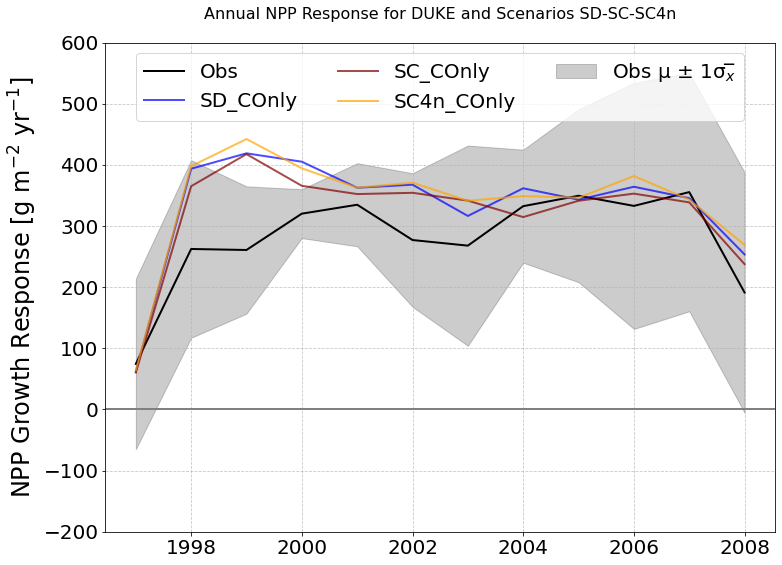

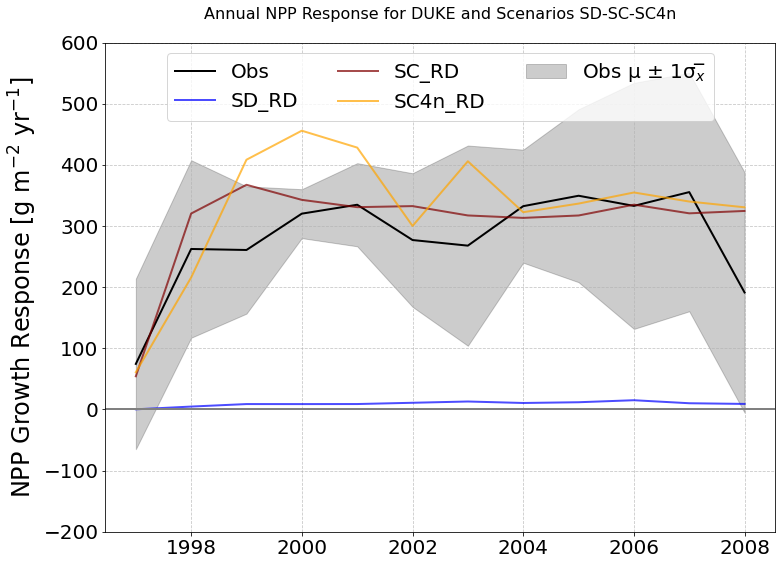

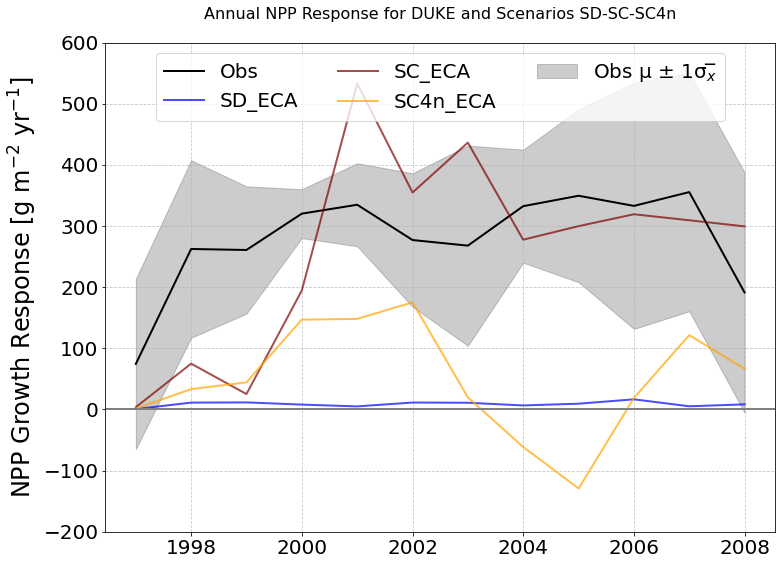

In [65]:
var_index = 0

# NPP Response for ORNL
select_site = "US-DUK"
site = "DUKE"
li = 0  # for legend index
plt.figure(figsize=(12, 9))
ran_once = False


for sim_index, sim_case in enumerate(sim_cases):
    plt.figure(figsize=(12, 9))
    ran_once = False
    for case_idx, case_plot in enumerate(list(case_abr.keys())):
        if True:
            var = var_names[var_index]
            for idx, key in enumerate(ds.keys()):
                if sim_case not in key:
                    continue
                if (f"{site}" in key) and (f"{case_plot}_" in key): 
                    time = pd.date_range(
                    "1996-01-01", "2007-12-31", freq="A"
                    )  # Yearly data
                    color_obs = "k"

                    if (obs_plot == 1) and (not ran_once):
                        Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                        Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                        Mean_DF = (
                            Mean_DF1[["YEAR", "NPP", "NUP"]]
                            - Mean_DF0[["YEAR", "NPP", "NUP"]]
                        )
                        Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                        Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                            drop=True
                        )
                        Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                            drop=True
                        )

                        Standard_error_DF = (
                            (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                            + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                        ) ** 0.5
                        Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                        tmp_case = ""

                        # Extracting the relevant columns
                        years = Mean_DF["YEAR"]
                        mean_npp = Mean_DF["NPP"]
                        se_npp = Standard_error_DF["NPP"]
                        # Plot NPP with shaded error bars
                        plt.plot(
                            time,
                            mean_npp,
                            label=f"Obs",
                            color=color_obs,
                            lw=2,
                        )
                        plt.fill_between(
                            time,
                            mean_npp - se_npp,
                            mean_npp + se_npp,
                            label=f"Obs μ ± 1σ$_x̅$",
                            color=color_obs,
                            alpha=0.2,
                        )
                        # data_plots_obs[site][var_obs][tmp_case] = {}
                        # data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                        # data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                        #plt.fill_between(
                        #    time,
                        #    mean_npp - se_npp * 1.96,
                        #    mean_npp + se_npp * 1.96,
                        #    color=color_obs,
                        #    alpha=0.15,
                        #)

                        ran_once = True

                    if "aCO2" in key:
                        #color_line = "blue"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        
                    if "eCO2" in key:
                        #color_line = "gray"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        continue
                    if var in ["FATES_NPP-FATES_EXCESS_RESP","NPP(GPPminusRA)"]:
                        tmp_var_a = (
                            (ds[key]["FATES_NPP"] - ds[key]["FATES_EXCESS_RESP"])
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        key_eCO2 = key.replace("aCO2", "eCO2")
                        tmp_var_e = (
                            (
                                ds[key_eCO2]["FATES_NPP"]
                                - ds[key_eCO2]["FATES_EXCESS_RESP"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )

                        plt.plot(
                            time,
                            (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                            label = f"{case_plot}_{sim_case}",
                            color=color_line,
                            marker=marker_line,
                            linestyle=line_style,
                            alpha=0.7,
                            linewidth=2,
                            markersize=10,
                        )
                        var_label_text = r"NPP (GPP${-}$RA)"
                    if var in ["NPP_alloc", "NPP_Growth"]:
                        tmp_var_a = (
                            (
                                ds[key]["FATES_CROOT_ALLOC"]
                                + ds[key]["FATES_FROOT_ALLOC"]
                                + ds[key]["FATES_LEAF_ALLOC"]
                                + ds[key]["FATES_SEED_ALLOC"]
                                + ds[key]["FATES_STEM_ALLOC"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        key_eCO2 = key.replace("aCO2", "eCO2")
                        tmp_var_e = (
                            (
                                ds[key_eCO2]["FATES_CROOT_ALLOC"]
                                + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                                + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                                + ds[key_eCO2]["FATES_SEED_ALLOC"]
                                + ds[key_eCO2]["FATES_STEM_ALLOC"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        plt.plot(
                            time,
                            (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                            # label=tmp_case
                            # .split("_")[-1]
                            # .replace("aCO2", "Response")
                            # + "_"
                            # + var,
                            label = f"{case_plot}_{sim_case}",
                            color=color_line,
                            marker=marker_line,
                            linestyle=line_style,
                            alpha=0.7,
                            linewidth=2,
                            markersize=10,
                        )
                        var_label_text = "NPP Growth"
                        
                    if False:
                        print(ds[key][var].long_name)
    plt.axhline(y=0, color="gray", lw=2, alpha=1)
    plt.grid(
        True, linestyle="--", alpha=0.7
    )  # Dashed grid lines with better visibility


    plt.ylabel(f"{var_label_text} "+ r"Response [g m$^{-2}$ yr$^{-1}$]", fontsize=fsize_labels)   
    plt.legend(fontsize=fsize_legend,loc="upper center", ncol=3)
    plt.xticks(fontsize=fsize_ticks)  # Increase x-axis tick font size
    plt.yticks(fontsize=fsize_ticks)  # Increase y-axis tick font size
    plt.ylim(ylim_response)
    plt.title(
        f"Annual NPP Response for {site} and Scenarios {'-'.join(list(case_abr.keys()))}\n",
        fontsize=16,
    )
    # li+=1 # for legend index updating for a sit

    print(
            f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf"
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )
    

### 2. FATES_NPP-FATES_EXCESS_RESPor NPP(GPPminusRA) or NPP(GPP-RA)

#### Change below

In [66]:
var_obs= "NPP"
var_names = ("NPP(GPPminusRA)",
             #"NPP_Growth",
            #"NPP(GPPminusRA)",
            #"FATES_NPP",
        #"FATES_NPP-FATES_EXCESS_RESP",
       )


ylim_variable = (0,2200)
ylim_response = (-200,700)

# plot obs? 
obs_plot = 1 # 0,1

sim_markers = ["<","<","<",">","<","^"]
sim_markers = ["","","",">","<","^"]
case_lines = ["-","-","-","-","-","_"]
case_colors = ["blue", "maroon", "orange"]

#### ORNL

/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP(GPPminusRA)_Response_COnly_SD-SC-SC4n_ORNL.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP(GPPminusRA)_Response_RD_SD-SC-SC4n_ORNL.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP(GPPminusRA)_Response_ECA_SD-SC-SC4n_ORNL.pdf


<Figure size 864x648 with 0 Axes>

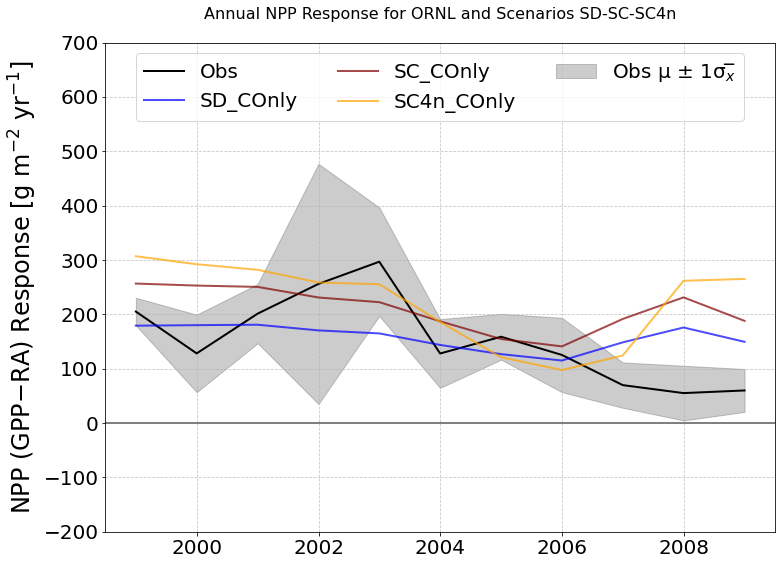

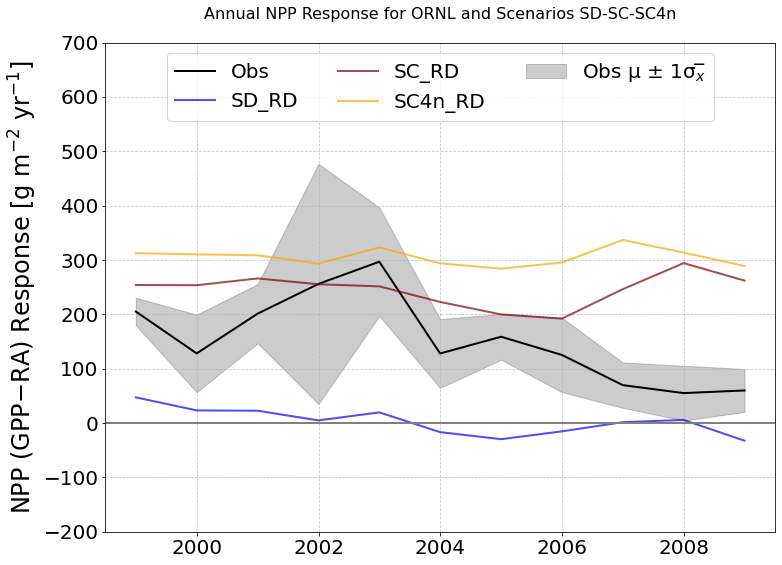

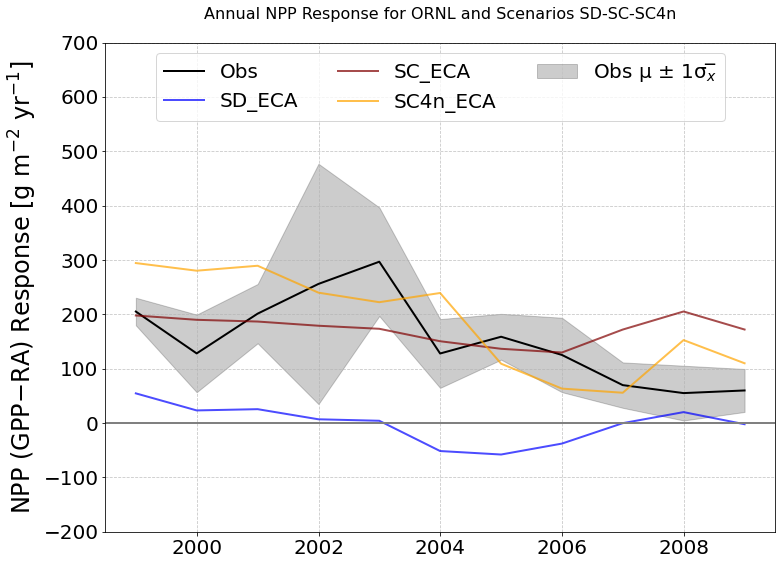

In [67]:
var_index = 0

# NPP Response for ORNL
select_site = "US-ORN"
site = "ORNL"
li = 0  # for legend index
plt.figure(figsize=(12, 9))
ran_once = False


for sim_index, sim_case in enumerate(sim_cases):
    plt.figure(figsize=(12, 9))
    ran_once = False
    for case_idx, case_plot in enumerate(list(case_abr.keys())):
        if True:
            var = var_names[var_index]
            for idx, key in enumerate(ds.keys()):
                if sim_case not in key:
                    continue
                if (f"{site}" in key) and (f"{case_plot}_" in key): 
                    time = pd.date_range(
                        "1998-01-01", "2008-12-31", freq="A"
                    )  # Monthly data
                    color_obs = "k"

                    if (obs_plot == 1) and (not ran_once):
                        Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                        Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                        Mean_DF = (
                            Mean_DF1[["YEAR", "NPP", "NUP"]]
                            - Mean_DF0[["YEAR", "NPP", "NUP"]]
                        )
                        Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                        Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                            drop=True
                        )
                        Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                            drop=True
                        )

                        Standard_error_DF = (
                            (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                            + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                        ) ** 0.5
                        Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                        tmp_case = ""

                        # Extracting the relevant columns
                        years = Mean_DF["YEAR"]
                        mean_npp = Mean_DF["NPP"]
                        se_npp = Standard_error_DF["NPP"]
                        # Plot NPP with shaded error bars
                        plt.plot(
                            time,
                            mean_npp,
                            label=f"Obs",
                            color=color_obs,
                            lw=2,
                        )
                        plt.fill_between(
                            time,
                            mean_npp - se_npp,
                            mean_npp + se_npp,
                            label=f"Obs μ ± 1σ$_x̅$",
                            color=color_obs,
                            alpha=0.2,
                        )
                        # data_plots_obs[site][var_obs][tmp_case] = {}
                        # data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                        # data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                        #plt.fill_between(
                        #    time,
                        #    mean_npp - se_npp * 1.96,
                        #    mean_npp + se_npp * 1.96,
                        #    color=color_obs,
                        #    alpha=0.15,
                        #)

                        ran_once = True

                    if "aCO2" in key:
                        #color_line = "blue"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        
                    if "eCO2" in key:
                        #color_line = "gray"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        continue
                    if var in ["FATES_NPP-FATES_EXCESS_RESP","NPP(GPPminusRA)"]:
                        tmp_var_a = (
                            (ds[key]["FATES_NPP"] - ds[key]["FATES_EXCESS_RESP"])
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        key_eCO2 = key.replace("aCO2", "eCO2")
                        tmp_var_e = (
                            (
                                ds[key_eCO2]["FATES_NPP"]
                                - ds[key_eCO2]["FATES_EXCESS_RESP"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )

                        plt.plot(
                            time,
                            (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                            label = f"{case_plot}_{sim_case}",
                            color=color_line,
                            marker=marker_line,
                            linestyle=line_style,
                            alpha=0.7,
                            linewidth=2,
                            markersize=10,
                        )
                        var_label_text = r"NPP (GPP${-}$RA)"
                    if var in ["NPP_alloc", "NPP_Growth"]:
                        tmp_var_a = (
                            (
                                ds[key]["FATES_CROOT_ALLOC"]
                                + ds[key]["FATES_FROOT_ALLOC"]
                                + ds[key]["FATES_LEAF_ALLOC"]
                                + ds[key]["FATES_SEED_ALLOC"]
                                + ds[key]["FATES_STEM_ALLOC"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        key_eCO2 = key.replace("aCO2", "eCO2")
                        tmp_var_e = (
                            (
                                ds[key_eCO2]["FATES_CROOT_ALLOC"]
                                + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                                + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                                + ds[key_eCO2]["FATES_SEED_ALLOC"]
                                + ds[key_eCO2]["FATES_STEM_ALLOC"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        plt.plot(
                            time,
                            (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                            # label=tmp_case
                            # .split("_")[-1]
                            # .replace("aCO2", "Response")
                            # + "_"
                            # + var,
                            label = f"{case_plot}_{sim_case}",
                            color=color_line,
                            marker=marker_line,
                            linestyle=line_style,
                            alpha=0.7,
                            linewidth=2,
                            markersize=10,
                        )
                        var_label_text = "NPP Growth"
                        
                    if False:
                        print(ds[key][var].long_name)
    plt.axhline(y=0, color="gray", lw=2, alpha=1)
    plt.grid(
        True, linestyle="--", alpha=0.7
    )  # Dashed grid lines with better visibility


    plt.ylabel(f"{var_label_text} "+ r"Response [g m$^{-2}$ yr$^{-1}$]", fontsize=fsize_labels)   
    plt.legend(fontsize=fsize_legend,loc="upper center", ncol=3)
    plt.xticks(fontsize=fsize_ticks)  # Increase x-axis tick font size
    plt.yticks(fontsize=fsize_ticks)  # Increase y-axis tick font size
    plt.ylim(ylim_response)
    plt.title(
        f"Annual NPP Response for {site} and Scenarios {'-'.join(list(case_abr.keys()))}\n",
        fontsize=16,
    )
    # li+=1 # for legend index updating for a sit

    print(
            f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf"
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )
    

#### DUKE 

/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP(GPPminusRA)_Response_COnly_SD-SC-SC4n_DUKE.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP(GPPminusRA)_Response_RD_SD-SC-SC4n_DUKE.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NPP(GPPminusRA)_Response_ECA_SD-SC-SC4n_DUKE.pdf


<Figure size 864x648 with 0 Axes>

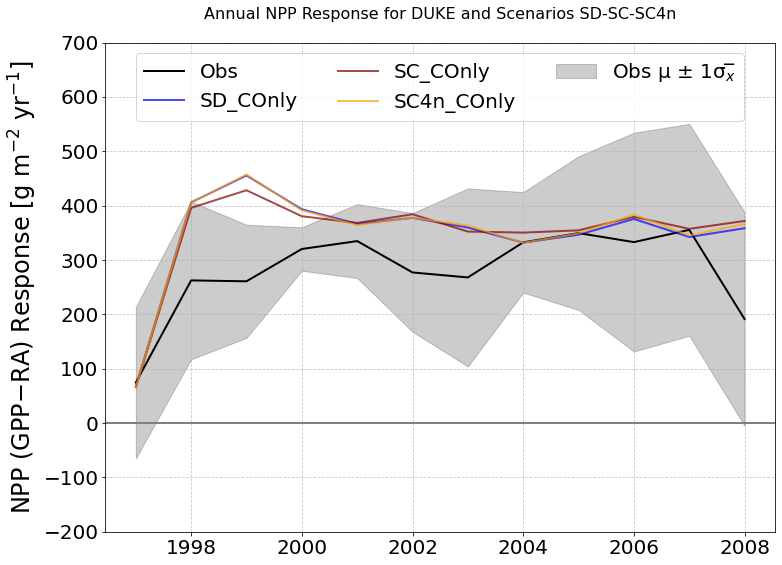

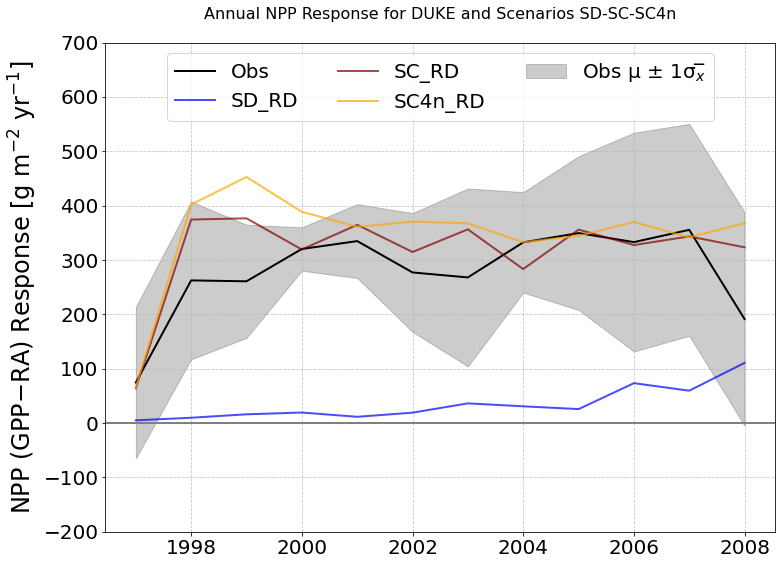

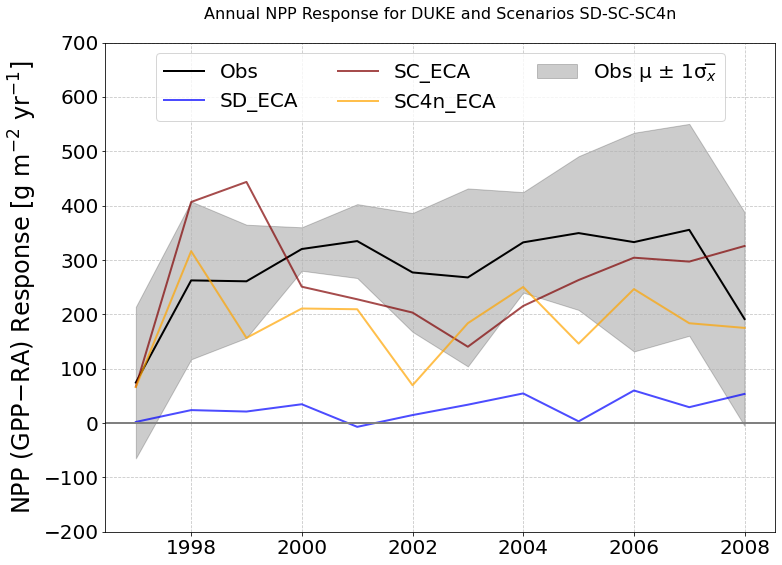

In [68]:
var_index = 0

# NPP Response for ORNL
select_site = "US-DUK"
site = "DUKE"
li = 0  # for legend index
plt.figure(figsize=(12, 9))
ran_once = False


for sim_index, sim_case in enumerate(sim_cases):
    plt.figure(figsize=(12, 9))
    ran_once = False
    for case_idx, case_plot in enumerate(list(case_abr.keys())):
        if True:
            var = var_names[var_index]
            for idx, key in enumerate(ds.keys()):
                if sim_case not in key:
                    continue
                if (f"{site}" in key) and (f"{case_plot}_" in key): 
                    time = pd.date_range(
                    "1996-01-01", "2007-12-31", freq="A"
                    )  # Yearly data
                    color_obs = "k"

                    if (obs_plot == 1) and (not ran_once):
                        Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                        Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                        Mean_DF = (
                            Mean_DF1[["YEAR", "NPP", "NUP"]]
                            - Mean_DF0[["YEAR", "NPP", "NUP"]]
                        )
                        Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                        Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                            drop=True
                        )
                        Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                            drop=True
                        )

                        Standard_error_DF = (
                            (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                            + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                        ) ** 0.5
                        Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                        tmp_case = ""

                        # Extracting the relevant columns
                        years = Mean_DF["YEAR"]
                        mean_npp = Mean_DF["NPP"]
                        se_npp = Standard_error_DF["NPP"]
                        # Plot NPP with shaded error bars
                        plt.plot(
                            time,
                            mean_npp,
                            label=f"Obs",
                            color=color_obs,
                            lw=2,
                        )
                        plt.fill_between(
                            time,
                            mean_npp - se_npp,
                            mean_npp + se_npp,
                            label=f"Obs μ ± 1σ$_x̅$",
                            color=color_obs,
                            alpha=0.2,
                        )
                        # data_plots_obs[site][var_obs][tmp_case] = {}
                        # data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                        # data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                        #plt.fill_between(
                        #    time,
                        #    mean_npp - se_npp * 1.96,
                        #    mean_npp + se_npp * 1.96,
                        #    color=color_obs,
                        #    alpha=0.15,
                        #)

                        ran_once = True

                    if "aCO2" in key:
                        #color_line = "blue"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        
                    if "eCO2" in key:
                        #color_line = "gray"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        continue
                    if var in ["FATES_NPP-FATES_EXCESS_RESP","NPP(GPPminusRA)"]:
                        tmp_var_a = (
                            (ds[key]["FATES_NPP"] - ds[key]["FATES_EXCESS_RESP"])
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        key_eCO2 = key.replace("aCO2", "eCO2")
                        tmp_var_e = (
                            (
                                ds[key_eCO2]["FATES_NPP"]
                                - ds[key_eCO2]["FATES_EXCESS_RESP"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )

                        plt.plot(
                            time,
                            (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                            label = f"{case_plot}_{sim_case}",
                            color=color_line,
                            marker=marker_line,
                            linestyle=line_style,
                            alpha=0.7,
                            linewidth=2,
                            markersize=10,
                        )
                        var_label_text = r"NPP (GPP${-}$RA)"
                    if var in ["NPP_alloc", "NPP_Growth"]:
                        tmp_var_a = (
                            (
                                ds[key]["FATES_CROOT_ALLOC"]
                                + ds[key]["FATES_FROOT_ALLOC"]
                                + ds[key]["FATES_LEAF_ALLOC"]
                                + ds[key]["FATES_SEED_ALLOC"]
                                + ds[key]["FATES_STEM_ALLOC"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        key_eCO2 = key.replace("aCO2", "eCO2")
                        tmp_var_e = (
                            (
                                ds[key_eCO2]["FATES_CROOT_ALLOC"]
                                + ds[key_eCO2]["FATES_FROOT_ALLOC"]
                                + ds[key_eCO2]["FATES_LEAF_ALLOC"]
                                + ds[key_eCO2]["FATES_SEED_ALLOC"]
                                + ds[key_eCO2]["FATES_STEM_ALLOC"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        plt.plot(
                            time,
                            (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                            # label=tmp_case
                            # .split("_")[-1]
                            # .replace("aCO2", "Response")
                            # + "_"
                            # + var,
                            label = f"{case_plot}_{sim_case}",
                            color=color_line,
                            marker=marker_line,
                            linestyle=line_style,
                            alpha=0.7,
                            linewidth=2,
                            markersize=10,
                        )
                        var_label_text = "NPP Growth"
                        
                    if False:
                        print(ds[key][var].long_name)
    plt.axhline(y=0, color="gray", lw=2, alpha=1)
    plt.grid(
        True, linestyle="--", alpha=0.7
    )  # Dashed grid lines with better visibility


    plt.ylabel(f"{var_label_text} "+ r"Response [g m$^{-2}$ yr$^{-1}$]", fontsize=fsize_labels)   
    plt.legend(fontsize=fsize_legend,loc="upper center", ncol=3)
    plt.xticks(fontsize=fsize_ticks)  # Increase x-axis tick font size
    plt.yticks(fontsize=fsize_ticks)  # Increase y-axis tick font size
    plt.ylim(ylim_response)
    plt.title(
        f"Annual NPP Response for {site} and Scenarios {'-'.join(list(case_abr.keys()))}\n",
        fontsize=16,
    )
    # li+=1 # for legend index updating for a sit

    print(
            f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf"
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )
    

### 3. NUP

#### Change below

In [69]:
var_obs= "NUP"
var_names = ("NUP",
             #"NPP_Growth",
       )

ylim_variable = (0,20)
ylim_response = (-2,7)

# plot obs? 
obs_plot = 1 # 0,1

sim_cases_N = sim_cases[1:]

sim_markers = ["<","<","<",">","<","^"][1:]
sim_markers = ["","","",">","<","^"][1:]
case_lines = ["-","-","-","-","-","_"]
case_colors = ["blue", "maroon", "orange"]



#### ORNL

/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NUP_Response_RD_SD-SC-SC4n_ORNL.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NUP_Response_ECA_SD-SC-SC4n_ORNL.pdf


<Figure size 864x648 with 0 Axes>

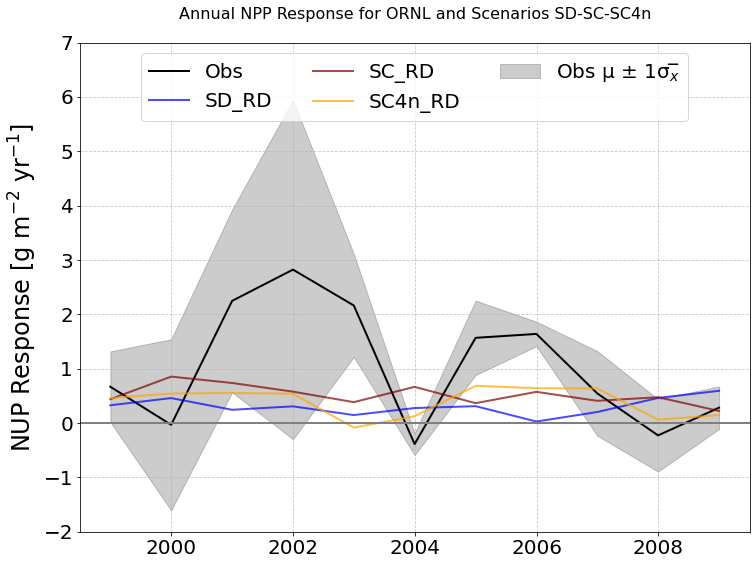

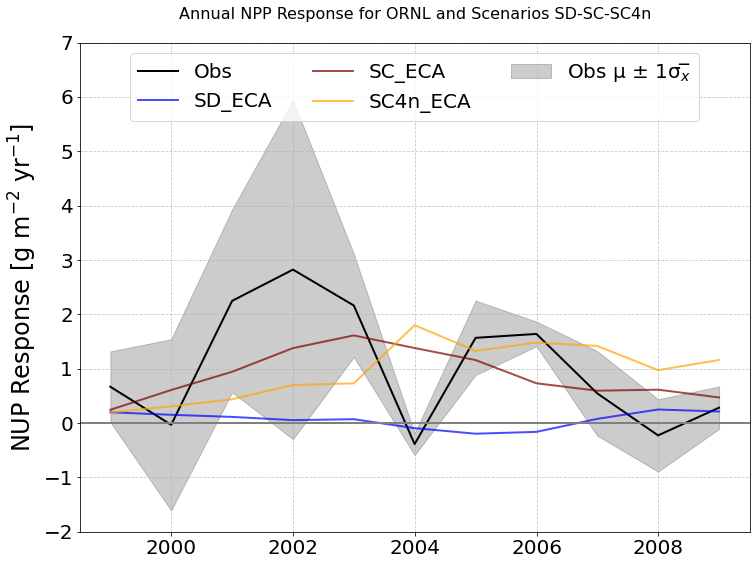

In [70]:
var_index = 0

# NPP Response for ORNL
select_site = "US-ORN"
site = "ORNL"
li = 0  # for legend index
plt.figure(figsize=(12, 9))
ran_once = False


for sim_index, sim_case in enumerate(sim_cases_N):
    plt.figure(figsize=(12, 9))
    ran_once = False
    for case_idx, case_plot in enumerate(list(case_abr.keys())):
        if True:
            var = var_names[var_index]
            for idx, key in enumerate(ds.keys()):
                if sim_case not in key:
                    continue
                if (f"{site}" in key) and (f"{case_plot}_" in key): 
                    time = pd.date_range(
                        "1998-01-01", "2008-12-31", freq="A"
                    )  # Monthly data
                    color_obs = "k"

                    if (obs_plot == 1) and (not ran_once):
                        Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                        Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                        Mean_DF = (
                            Mean_DF1[["YEAR", "NPP", "NUP"]]
                            - Mean_DF0[["YEAR", "NPP", "NUP"]]
                        )
                        Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                        Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                            drop=True
                        )
                        Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                            drop=True
                        )

                        Standard_error_DF = (
                            (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                            + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                        ) ** 0.5
                        Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                        tmp_case = ""

                        # Extracting the relevant columns
                        years = Mean_DF["YEAR"]
                        mean_npp = Mean_DF[f"{var_obs}"]
                        se_npp = Standard_error_DF[f"{var_obs}"]
                        # Plot NPP with shaded error bars
                        plt.plot(
                            time,
                            mean_npp,
                            label=f"Obs",
                            color=color_obs,
                            lw=2,
                        )
                        plt.fill_between(
                            time,
                            mean_npp - se_npp,
                            mean_npp + se_npp,
                            label=f"Obs μ ± 1σ$_x̅$",
                            color=color_obs,
                            alpha=0.2,
                        )
                        # data_plots_obs[site][var_obs][tmp_case] = {}
                        # data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                        # data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                        #plt.fill_between(
                        #    time,
                        #    mean_npp - se_npp * 1.96,
                        #    mean_npp + se_npp * 1.96,
                        #    color=color_obs,
                        #    alpha=0.15,
                        #)

                        ran_once = True

                    if "aCO2" in key:
                        #color_line = "blue"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        
                    if "eCO2" in key:
                        #color_line = "gray"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        continue
                    if var in ["NUP"]:
                        tmp_var_a = (
                            (
                                ds[key]["FATES_NH4UPTAKE"]
                                + ds[key]["FATES_NO3UPTAKE"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        key_eCO2 = key.replace("aCO2", "eCO2")
                        tmp_var_e = (
                            (
                                ds[key_eCO2]["FATES_NH4UPTAKE"]
                                + ds[key_eCO2]["FATES_NO3UPTAKE"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        plt.plot(
                            time,
                            (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                            label = f"{case_plot}_{sim_case}",
                            color=color_line,
                            marker=marker_line,
                            linestyle=line_style,
                            alpha=0.7,
                            linewidth=2,
                            markersize=10,
                        )
                        var_label_text = "NUP"
                        
                    if False:
                        print(ds[key][var].long_name)
    plt.axhline(y=0, color="gray", lw=2, alpha=1)
    plt.grid(
        True, linestyle="--", alpha=0.7
    )  # Dashed grid lines with better visibility


    plt.ylabel(f"{var_label_text} "+ r"Response [g m$^{-2}$ yr$^{-1}$]", fontsize=fsize_labels)   
    plt.legend(fontsize=fsize_legend,loc="upper center", ncol=3)
    plt.xticks(fontsize=fsize_ticks)  # Increase x-axis tick font size
    plt.yticks(fontsize=fsize_ticks)  # Increase y-axis tick font size
    plt.ylim(ylim_response)
    plt.title(
        f"Annual NPP Response for {site} and Scenarios {'-'.join(list(case_abr.keys()))}\n",
        fontsize=16,
    )
    # li+=1 # for legend index updating for a sit

    print(
            f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf"
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )
    

#### DUKE

/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NUP_Response_RD_SD-SC-SC4n_DUKE.pdf
/Users/ud4/Documents/FACEMDS/Figures_Paper/CommonL2_NUP_Response_ECA_SD-SC-SC4n_DUKE.pdf


<Figure size 864x648 with 0 Axes>

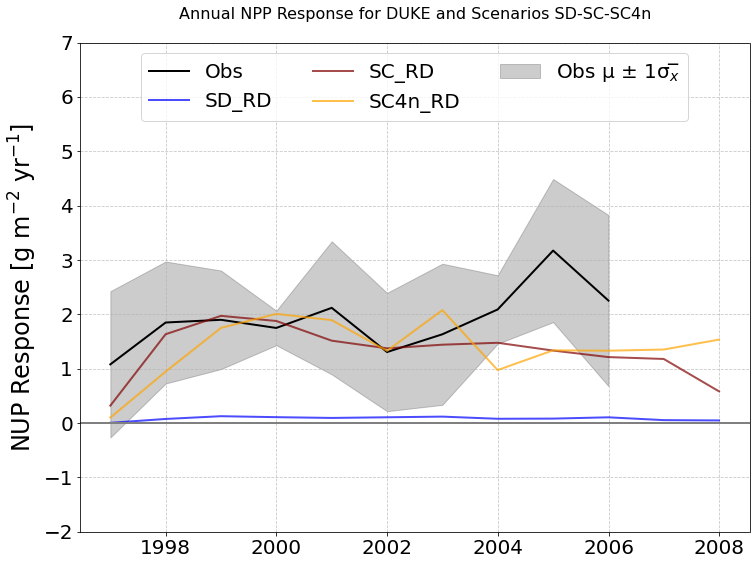

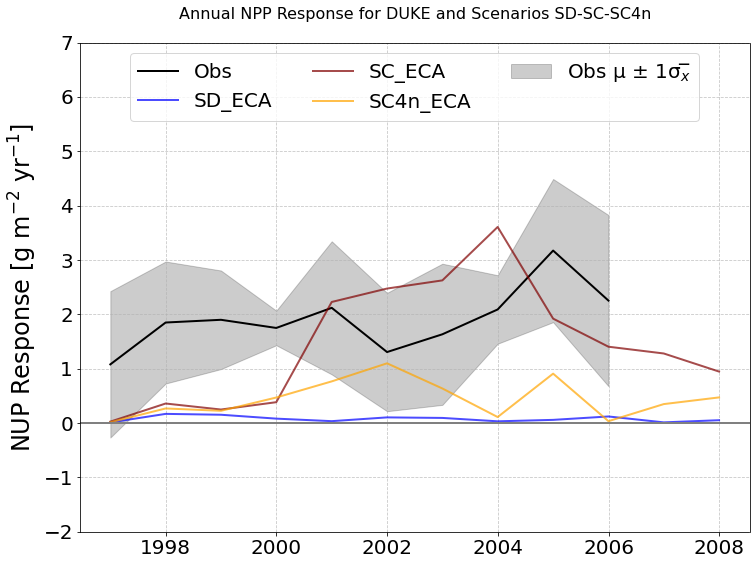

In [71]:
var_index = 0

# NPP Response for ORNL
select_site = "US-DUK"
site = "DUKE"
li = 0  # for legend index
plt.figure(figsize=(12, 9))
ran_once = False

for sim_index, sim_case in enumerate(sim_cases_N):
    plt.figure(figsize=(12, 9))
    ran_once = False
    for case_idx, case_plot in enumerate(list(case_abr.keys())):
        if True:
            var = var_names[var_index]
            for idx, key in enumerate(ds.keys()):
                if sim_case not in key:
                    continue
                if (f"{site}" in key) and (f"{case_plot}_" in key): 
                    time = pd.date_range(
                    "1996-01-01", "2007-12-31", freq="A"
                )  # Yearly data
                    color_obs = "k"

                    if (obs_plot == 1) and (not ran_once):
                        Mean_DF1 = dict_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
                        Mean_DF0 = dict_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

                        Mean_DF = (
                            Mean_DF1[["YEAR", "NPP", "NUP"]]
                            - Mean_DF0[["YEAR", "NPP", "NUP"]]
                        )
                        Mean_DF["YEAR"] = Mean_DF1["YEAR"]

                        Standard_error_DF1 = dict_obs_ase[site][CO2_cases[1]].reset_index(
                            drop=True
                        )
                        Standard_error_DF0 = dict_obs_ase[site][CO2_cases[0]].reset_index(
                            drop=True
                        )

                        Standard_error_DF = (
                            (Standard_error_DF1[["YEAR", "NPP", "NUP"]]) ** 2
                            + (Standard_error_DF0[["YEAR", "NPP", "NUP"]]) ** 2
                        ) ** 0.5
                        Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]
                        tmp_case = ""

                        # Extracting the relevant columns
                        years = Mean_DF["YEAR"]
                        mean_npp = Mean_DF[f"{var_obs}"]
                        se_npp = Standard_error_DF[f"{var_obs}"]
                        # Plot NPP with shaded error bars
                        plt.plot(
                            time,
                            mean_npp,
                            label=f"Obs",
                            color=color_obs,
                            lw=2,
                        )
                        plt.fill_between(
                            time,
                            mean_npp - se_npp,
                            mean_npp + se_npp,
                            label=f"Obs μ ± 1σ$_x̅$",
                            color=color_obs,
                            alpha=0.2,
                        )
                        # data_plots_obs[site][var_obs][tmp_case] = {}
                        # data_plots_obs[site][var_obs][tmp_case]["time"] = np.array([t.year for t in time])
                        # data_plots_obs[site][var_obs][tmp_case]["mean_npp"] = np.array(mean_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_lower"] = np.array(mean_npp - se_npp)
                        # data_plots_obs[site][var_obs][tmp_case]["npp_1sd_upper"] = np.array(mean_npp + se_npp)
                        #plt.fill_between(
                        #    time,
                        #    mean_npp - se_npp * 1.96,
                        #    mean_npp + se_npp * 1.96,
                        #    color=color_obs,
                        #    alpha=0.15,
                        #)

                        ran_once = True

                    if "aCO2" in key:
                        #color_line = "blue"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        
                    if "eCO2" in key:
                        #color_line = "gray"
                        #marker_line = "^"
                        line_style  = case_lines    [case_idx]
                        marker_line = sim_markers  [sim_index]
                        color_line  = case_colors   [case_idx]
                        continue
                    if var in ["NUP"]:
                        tmp_var_a = (
                            (
                                ds[key]["FATES_NH4UPTAKE"]
                                + ds[key]["FATES_NO3UPTAKE"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        key_eCO2 = key.replace("aCO2", "eCO2")
                        tmp_var_e = (
                            (
                                ds[key_eCO2]["FATES_NH4UPTAKE"]
                                + ds[key_eCO2]["FATES_NO3UPTAKE"]
                            )
                            * 24
                            * 3600
                            * 365
                            * 1000
                        )
                        plt.plot(
                            time,
                            (tmp_var_e - tmp_var_a).groupby("time.year").mean(),
                            label = f"{case_plot}_{sim_case}",
                            color=color_line,
                            marker=marker_line,
                            linestyle=line_style,
                            alpha=0.7,
                            linewidth=2,
                            markersize=10,
                        )
                        var_label_text = "NUP"
                        
                    if False:
                        print(ds[key][var].long_name)
    plt.axhline(y=0, color="gray", lw=2, alpha=1)
    plt.grid(
        True, linestyle="--", alpha=0.7
    )  # Dashed grid lines with better visibility


    plt.ylabel(f"{var_label_text} "+ r"Response [g m$^{-2}$ yr$^{-1}$]", fontsize=fsize_labels)   
    plt.legend(fontsize=fsize_legend,loc="upper center", ncol=3)
    plt.xticks(fontsize=fsize_ticks)  # Increase x-axis tick font size
    plt.yticks(fontsize=fsize_ticks)  # Increase y-axis tick font size
    plt.ylim(ylim_response)
    plt.title(
        f"Annual NPP Response for {site} and Scenarios {'-'.join(list(case_abr.keys()))}\n",
        fontsize=16,
    )
    # li+=1 # for legend index updating for a sit

    print(
            f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf"
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.pdf",
        format="pdf",
        bbox_inches="tight",
    )
    plt.savefig(
         f"{path_save_results}/CommonL2_{var}_Response_{sim_case}_{'-'.join(list(case_abr.keys()))}_{site}.png",
        format="png",
        dpi=200,
        bbox_inches="tight",
    )
    